# Anchor Reconstruction Experiment (v2 — Fixed)

**Hypothesis:** Concept representations in transformer activation space are effectively low-rank.
K anchor concepts (K << N) suffice to reconstruct the pairwise geometry of N concepts with bounded error.

**Method:** Nyström kernel approximation on cosine **similarity** (PSD kernel).

v1 used MDS on cosine *distances* which is invalid (not Euclidean → numerical blowup).

In [1]:
import sys
sys.path.insert(0, '../backend')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from app.extractor import ModelExtractor

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'monospace'

## 1. Concept Vocabulary (200 concepts, 10 categories)

In [2]:
CONCEPTS = {
    "emotions": [
        "love", "fear", "joy", "anger", "sadness", "hope",
        "trust", "surprise", "guilt", "pride", "shame", "compassion",
        "anxiety", "envy", "disgust", "gratitude", "loneliness", "awe",
        "contempt", "nostalgia",
    ],
    "relations": [
        "friend", "enemy", "parent", "child", "teacher", "student",
        "ally", "rival", "partner", "stranger", "leader", "follower",
        "husband", "wife", "sibling", "neighbor", "master", "servant",
        "king", "citizen",
    ],
    "abstractions": [
        "truth", "justice", "beauty", "freedom", "time", "death",
        "life", "power", "knowledge", "meaning", "order", "chaos",
        "fate", "duty", "honor", "virtue", "sin", "mercy",
        "wisdom", "courage",
    ],
    "states": [
        "alive", "dead", "happy", "sad", "sick", "healthy",
        "young", "old", "strong", "weak", "awake", "asleep",
        "hungry", "tired", "calm", "confused", "lost", "safe",
        "free", "trapped",
    ],
    "nature": [
        "water", "fire", "earth", "sky", "sun", "moon",
        "stone", "tree", "mountain", "ocean", "wind", "light",
        "rain", "snow", "river", "forest", "desert", "star",
        "flower", "seed",
    ],
    "mind": [
        "thought", "belief", "desire", "memory", "dream",
        "consciousness", "reason", "emotion", "will", "perception",
        "attention", "imagination", "intuition", "logic", "doubt",
        "understanding", "insight", "awareness", "intention", "curiosity",
    ],
    "body": [
        "hand", "eye", "heart", "blood", "bone", "skin",
        "breath", "voice", "face", "brain", "muscle", "nerve",
        "tongue", "finger", "chest", "shoulder", "spine", "skull",
        "wound", "scar",
    ],
    "society": [
        "war", "peace", "law", "crime", "money", "church",
        "school", "prison", "market", "army", "nation", "tribe",
        "democracy", "empire", "revolution", "tradition", "culture", "ritual",
        "language", "family",
    ],
    "objects": [
        "book", "sword", "door", "mirror", "ship", "bridge",
        "wall", "key", "crown", "mask", "chain", "wheel",
        "bell", "cup", "flag", "rope", "hammer", "candle",
        "clock", "coin",
    ],
    "actions": [
        "create", "destroy", "build", "break", "give", "take",
        "speak", "listen", "fight", "heal", "grow", "decay",
        "search", "hide", "remember", "forget", "choose", "sacrifice",
        "betray", "forgive",
    ],
}

concept_list = []
concept_categories = []
for cat, words in CONCEPTS.items():
    for w in words:
        concept_list.append(w)
        concept_categories.append(cat)

N = len(concept_list)
print(f"{N} concepts across {len(CONCEPTS)} categories")

200 concepts across 10 categories


## 2. Embed All Concepts

In [3]:
extractor = ModelExtractor("pythia-70m")

print(f"Embedding {N} concepts...")
streams = []
for i, concept in enumerate(concept_list):
    stream = extractor.extract_concept_stream(concept)
    streams.append(stream)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{N}")

streams = np.stack(streams)  # [N, n_layers+1, d_model]
print(f"Done. Shape: {streams.shape}")

Loading pythia-70m on cpu...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model pythia-70m into HookedTransformer
Loaded. Layers: 6, d_model: 512, heads: 8
Embedding 200 concepts...
  50/200
  100/200
  150/200
  200/200
Done. Shape: (200, 7, 512)


## 3. Ground Truth

Distance matrix: (200, 200)
  min: 0.0000, max: 1.8713, mean: 0.9988


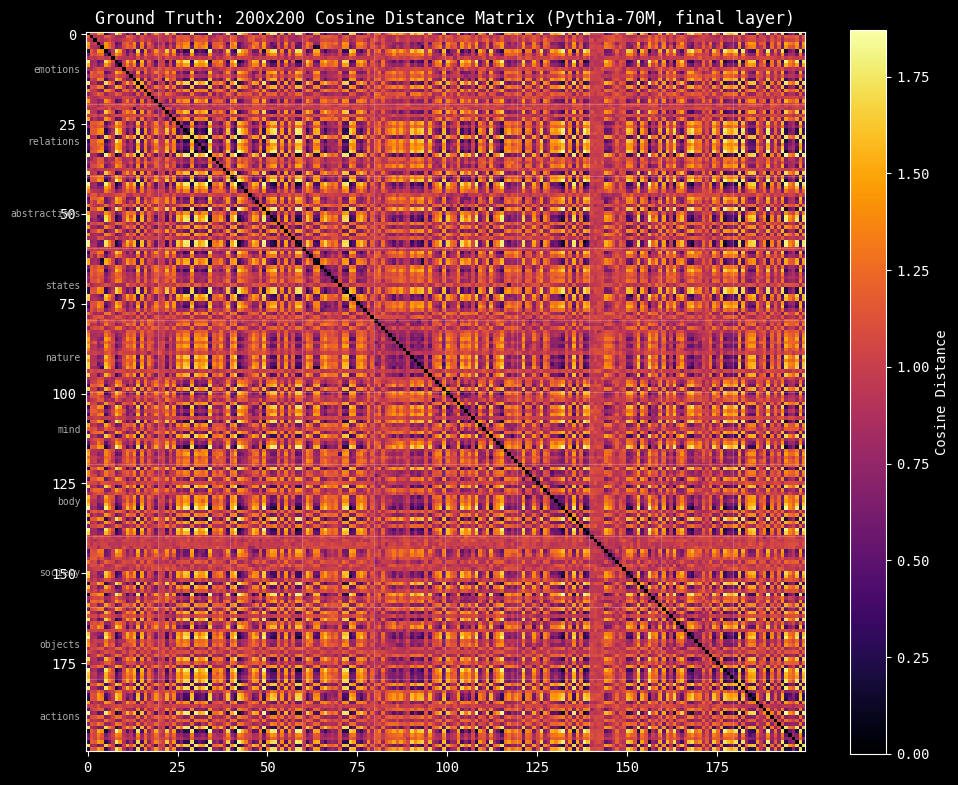

In [4]:
final_reps = streams[:, -1, :]  # [N, d_model]
final_centered = final_reps - final_reps.mean(axis=0)

# Ground truth matrices
S_true = cosine_similarity(final_centered)  # [N, N] — PSD kernel
D_true = 1.0 - S_true                        # cosine distance

print(f"Distance matrix: {D_true.shape}")
print(f"  min: {D_true[D_true > 0].min():.4f}, max: {D_true.max():.4f}, mean: {D_true.mean():.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(D_true, cmap='inferno', aspect='equal')
plt.colorbar(im, label='Cosine Distance')
cats = list(CONCEPTS.keys())
boundaries = [0]
for cat in cats:
    boundaries.append(boundaries[-1] + len(CONCEPTS[cat]))
for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color='white', linewidth=0.5, alpha=0.3)
    ax.axvline(b - 0.5, color='white', linewidth=0.5, alpha=0.3)
for i, cat in enumerate(cats):
    mid = (boundaries[i] + boundaries[i+1]) / 2
    ax.text(-2, mid, cat, ha='right', va='center', fontsize=7, color='#aaa')
ax.set_title(f'Ground Truth: {N}x{N} Cosine Distance Matrix (Pythia-70M, final layer)')
plt.tight_layout()
plt.show()

## 4. Reconstruction via Nyström Kernel Approximation

**Why not MDS on distances?** Cosine distance is not Euclidean — the double-centered
Gram matrix gets large negative eigenvalues and MDS/Nyström blows up numerically.

**Correct approach:** Cosine similarity IS a valid PSD kernel. The Nyström approximation
on a PSD kernel is mathematically well-posed: S ≈ S_nk @ pinv(S_kk) @ S_kn.

In [5]:
def nystrom_reconstruct(S_true, anchor_indices):
    """
    Nyström kernel approximation: reconstruct N×N similarity matrix
    from N×K and K×K submatrices.
    
    S ≈ S_nk @ pinv(S_kk) @ S_kn
    Exact when rank(S) ≤ K.
    """
    S_nk = S_true[:, anchor_indices]          # [N, K]
    S_kk = S_true[np.ix_(anchor_indices, anchor_indices)]  # [K, K]
    
    # Regularized pseudoinverse
    eigvals, eigvecs = np.linalg.eigh(S_kk)
    thresh = max(1e-10, eigvals.max() * 1e-8)
    valid = eigvals > thresh
    S_kk_pinv = (eigvecs[:, valid] / eigvals[valid]) @ eigvecs[:, valid].T
    
    S_recon = S_nk @ S_kk_pinv @ S_nk.T
    return S_recon


def rel_frobenius_error(D_true, D_recon):
    """Relative Frobenius error on upper triangle."""
    mask = np.triu(np.ones_like(D_true, dtype=bool), k=1)
    return float(np.linalg.norm(D_true[mask] - D_recon[mask]) / np.linalg.norm(D_true[mask]))


def rank_corr(D_true, D_recon):
    """Spearman rank correlation on upper triangle."""
    mask = np.triu(np.ones_like(D_true, dtype=bool), k=1)
    rho, _ = spearmanr(D_true[mask], D_recon[mask])
    return float(rho)


# Quick sanity check: K=N should give ~0 error
S_test = nystrom_reconstruct(S_true, np.arange(N))
D_test = 1.0 - S_test
print(f"Sanity check (K=N): error = {rel_frobenius_error(D_true, D_test):.6f}")

Sanity check (K=N): error = 0.000006


In [6]:
# Run experiment
K_values = [3, 4, 5, 6, 8, 10, 15, 20, 30, 50, 75, 100]
n_trials = 20
rng = np.random.RandomState(42)

results = []

for K in K_values:
    trial_errors = []
    trial_ranks = []
    
    for trial in range(n_trials):
        anchor_idx = rng.choice(N, size=K, replace=False)
        S_recon = nystrom_reconstruct(S_true, anchor_idx)
        D_recon = 1.0 - S_recon
        
        trial_errors.append(rel_frobenius_error(D_true, D_recon))
        trial_ranks.append(rank_corr(D_true, D_recon))
    
    results.append({
        'K': K,
        'mean_error': np.mean(trial_errors),
        'std_error': np.std(trial_errors),
        'mean_rho': np.mean(trial_ranks),
        'std_rho': np.std(trial_ranks),
    })
    
    print(f"K={K:3d}  |  error = {results[-1]['mean_error']:.4f} ± {results[-1]['std_error']:.4f}  |  ρ = {results[-1]['mean_rho']:.4f} ± {results[-1]['std_rho']:.4f}")

print("\nDone.")

K=  3  |  error = 0.1240 ± 0.0510  |  ρ = 0.9643 ± 0.0131
K=  4  |  error = 0.1065 ± 0.0408  |  ρ = 0.9704 ± 0.0076
K=  5  |  error = 0.0969 ± 0.0405  |  ρ = 0.9723 ± 0.0073
K=  6  |  error = 0.0828 ± 0.0293  |  ρ = 0.9757 ± 0.0036
K=  8  |  error = 0.0665 ± 0.0077  |  ρ = 0.9795 ± 0.0008
K= 10  |  error = 0.0620 ± 0.0077  |  ρ = 0.9808 ± 0.0011
K= 15  |  error = 0.0526 ± 0.0108  |  ρ = 0.9849 ± 0.0011
K= 20  |  error = 0.0441 ± 0.0021  |  ρ = 0.9876 ± 0.0007
K= 30  |  error = 0.0369 ± 0.0009  |  ρ = 0.9909 ± 0.0006
K= 50  |  error = 0.0270 ± 0.0006  |  ρ = 0.9950 ± 0.0003
K= 75  |  error = 0.0192 ± 0.0008  |  ρ = 0.9974 ± 0.0003
K=100  |  error = 0.0131 ± 0.0005  |  ρ = 0.9988 ± 0.0001

Done.


## 5. Error-vs-K Curve

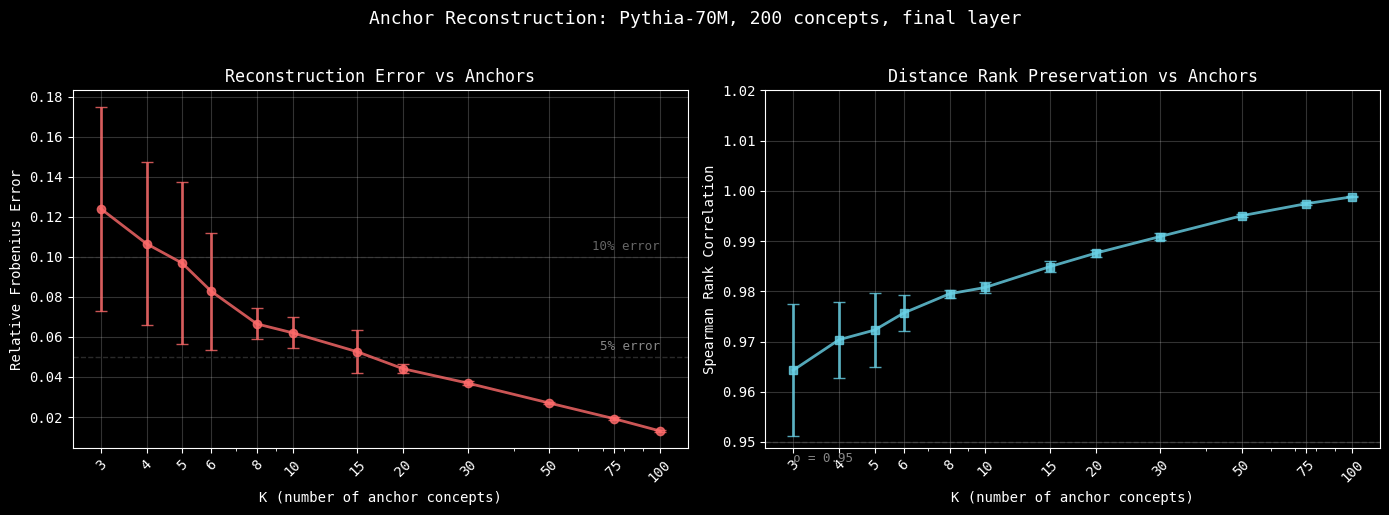

In [7]:
Ks = [r['K'] for r in results]
errors = [r['mean_error'] for r in results]
error_stds = [r['std_error'] for r in results]
rhos = [r['mean_rho'] for r in results]
rho_stds = [r['std_rho'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.errorbar(Ks, errors, yerr=error_stds, marker='o', linewidth=2,
             capsize=4, color='#ff6b6b', ecolor='#ff6b6b', alpha=0.8)
ax1.axhline(0.05, color='#555', linestyle='--', linewidth=1, alpha=0.5)
ax1.text(Ks[-1], 0.052, '5% error', ha='right', va='bottom', fontsize=9, color='#888')
ax1.axhline(0.10, color='#555', linestyle='--', linewidth=1, alpha=0.3)
ax1.text(Ks[-1], 0.102, '10% error', ha='right', va='bottom', fontsize=9, color='#666')
ax1.set_xlabel('K (number of anchor concepts)')
ax1.set_ylabel('Relative Frobenius Error')
ax1.set_title('Reconstruction Error vs Anchors')
ax1.set_xscale('log')
ax1.set_xticks(Ks)
ax1.set_xticklabels([str(k) for k in Ks], rotation=45)
ax1.grid(True, alpha=0.2)

ax2.errorbar(Ks, rhos, yerr=rho_stds, marker='s', linewidth=2,
             capsize=4, color='#69d2e7', ecolor='#69d2e7', alpha=0.8)
ax2.axhline(0.95, color='#555', linestyle='--', linewidth=1, alpha=0.5)
ax2.text(Ks[0], 0.948, 'ρ = 0.95', ha='left', va='top', fontsize=9, color='#888')
ax2.set_xlabel('K (number of anchor concepts)')
ax2.set_ylabel('Spearman Rank Correlation')
ax2.set_title('Distance Rank Preservation vs Anchors')
ax2.set_xscale('log')
ax2.set_xticks(Ks)
ax2.set_xticklabels([str(k) for k in Ks], rotation=45)
ax2.set_ylim(None, 1.02)
ax2.grid(True, alpha=0.2)

plt.suptitle('Anchor Reconstruction: Pythia-70M, 200 concepts, final layer', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 6. PCA Intrinsic Dimensionality

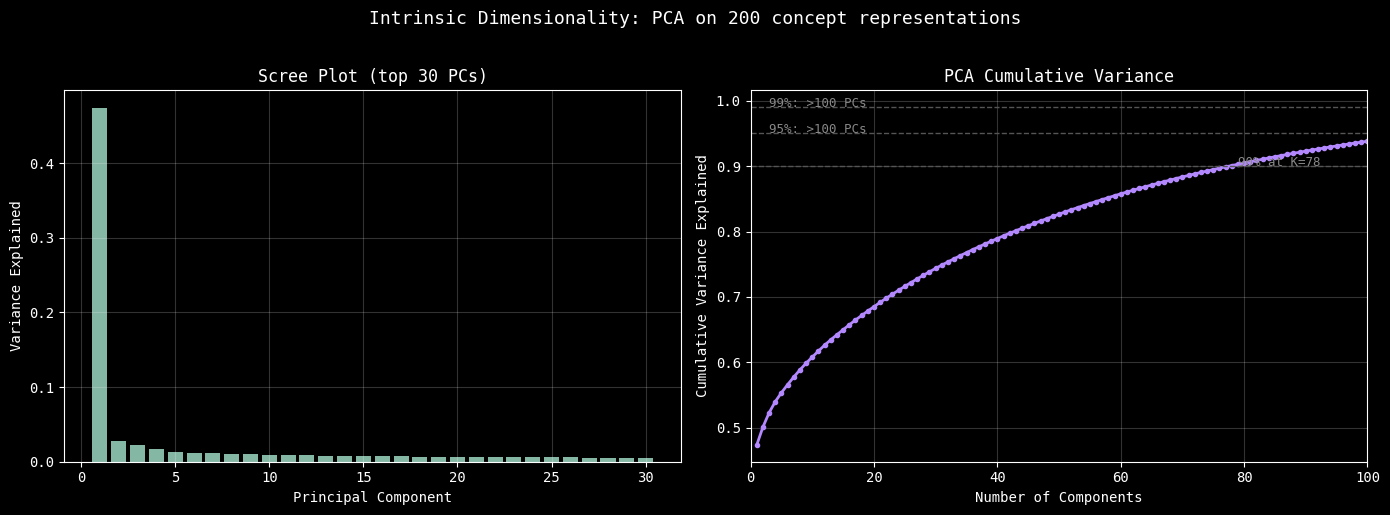

Components for 90% variance: 78
Components for 95% variance: >100 (not reached)
Components for 99% variance: >100 (not reached)


In [8]:
pca_full = PCA(n_components=min(100, N))
pca_full.fit(final_centered)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

def find_k(cumvar, threshold):
    hits = np.where(cumvar >= threshold)[0]
    return int(hits[0] + 1) if len(hits) > 0 else None

k90 = find_k(cumvar, 0.90)
k95 = find_k(cumvar, 0.95)
k99 = find_k(cumvar, 0.99)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color='#a8e6cf', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('Scree Plot (top 30 PCs)')
ax1.grid(True, alpha=0.2)

ax2.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#b388ff', linewidth=2, markersize=3)
ax2.axhline(0.90, color='#555', linestyle='--', linewidth=1)
ax2.axhline(0.95, color='#555', linestyle='--', linewidth=1)
ax2.axhline(0.99, color='#555', linestyle='--', linewidth=1)
for k, t in [(k90, 0.90), (k95, 0.95), (k99, 0.99)]:
    label = f'{t:.0%} at K={k}' if k else f'{t:.0%}: >{len(cumvar)} PCs'
    xpos = (k if k else 2) + 1
    ax2.text(xpos, t, label, fontsize=9, color='#888')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('PCA Cumulative Variance')
ax2.set_xlim(0, len(cumvar))
ax2.grid(True, alpha=0.2)

plt.suptitle('Intrinsic Dimensionality: PCA on 200 concept representations', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

for label, k in [('90%', k90), ('95%', k95), ('99%', k99)]:
    print(f"Components for {label} variance: {k if k else '>100 (not reached)'}")

## 7. Layer-by-Layer Analysis

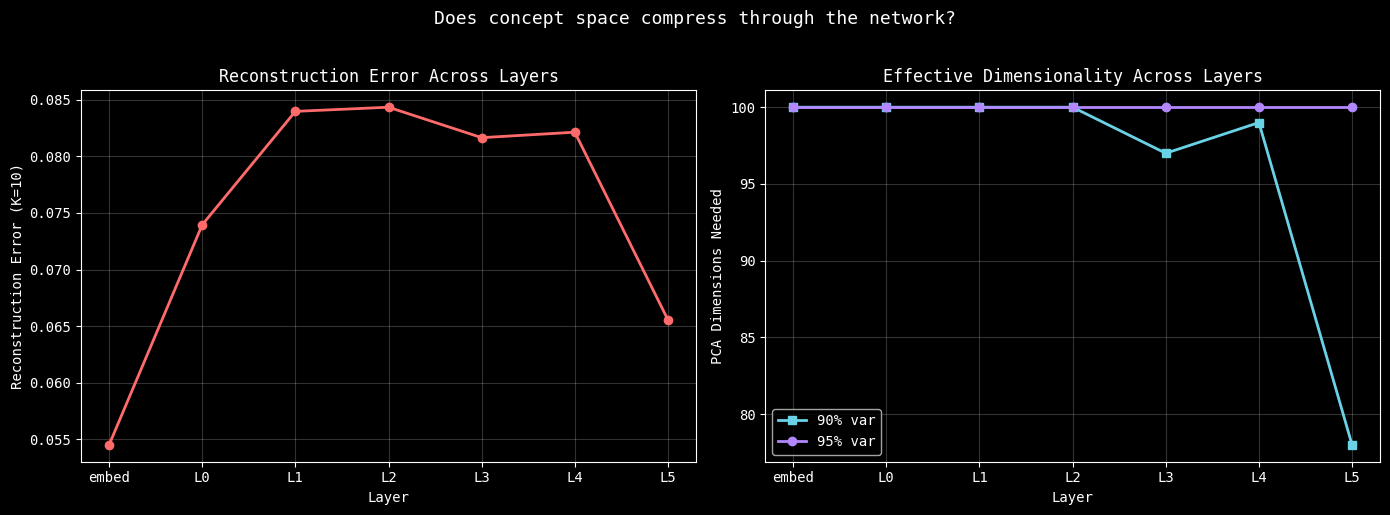

embed   |  recon error (K=10): 0.0545  |  90%: 100 dims  |  95%: 100 dims
L0      |  recon error (K=10): 0.0740  |  90%: 100 dims  |  95%: 100 dims
L1      |  recon error (K=10): 0.0840  |  90%: 100 dims  |  95%: 100 dims
L2      |  recon error (K=10): 0.0843  |  90%: 100 dims  |  95%: 100 dims
L3      |  recon error (K=10): 0.0817  |  90%: 97 dims  |  95%: 100 dims
L4      |  recon error (K=10): 0.0821  |  90%: 99 dims  |  95%: 100 dims
L5      |  recon error (K=10): 0.0656  |  90%: 78 dims  |  95%: 100 dims


In [9]:
n_layer_steps = streams.shape[1]
K_test = 10

layer_errors = []
layer_dims_90 = []
layer_dims_95 = []

for layer in range(n_layer_steps):
    reps = streams[:, layer, :]
    reps_c = reps - reps.mean(axis=0)
    S_layer = cosine_similarity(reps_c)
    D_layer = 1.0 - S_layer
    
    trial_errs = []
    for trial in range(20):
        anchor_idx = rng.choice(N, size=K_test, replace=False)
        S_recon = nystrom_reconstruct(S_layer, anchor_idx)
        D_recon = 1.0 - S_recon
        trial_errs.append(rel_frobenius_error(D_layer, D_recon))
    layer_errors.append(np.mean(trial_errs))
    
    pca_layer = PCA(n_components=min(100, N))
    pca_layer.fit(reps_c)
    cv = np.cumsum(pca_layer.explained_variance_ratio_)
    layer_dims_90.append(find_k(cv, 0.90) or len(cv))
    layer_dims_95.append(find_k(cv, 0.95) or len(cv))

layer_labels = ['embed'] + [f'L{i}' for i in range(n_layer_steps - 1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(n_layer_steps), layer_errors, 'o-', color='#ff6b6b', linewidth=2)
ax1.set_xticks(range(n_layer_steps))
ax1.set_xticklabels(layer_labels)
ax1.set_xlabel('Layer')
ax1.set_ylabel('Reconstruction Error (K=10)')
ax1.set_title('Reconstruction Error Across Layers')
ax1.grid(True, alpha=0.2)

ax2.plot(range(n_layer_steps), layer_dims_90, 's-', color='#69d2e7', linewidth=2, label='90% var')
ax2.plot(range(n_layer_steps), layer_dims_95, 'o-', color='#b388ff', linewidth=2, label='95% var')
ax2.set_xticks(range(n_layer_steps))
ax2.set_xticklabels(layer_labels)
ax2.set_xlabel('Layer')
ax2.set_ylabel('PCA Dimensions Needed')
ax2.set_title('Effective Dimensionality Across Layers')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.suptitle('Does concept space compress through the network?', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

for i, label in enumerate(layer_labels):
    print(f"{label:6s}  |  recon error (K=10): {layer_errors[i]:.4f}  |  90%: {layer_dims_90[i]} dims  |  95%: {layer_dims_95[i]} dims")

## 8. Summary

In [10]:
print("=" * 65)
print("ANCHOR RECONSTRUCTION EXPERIMENT — SUMMARY")
print("=" * 65)
print(f"Model: Pythia-70M ({extractor.n_layers} layers, d={extractor.d_model})")
print(f"Concepts: {N} across {len(CONCEPTS)} categories")
print(f"Method: Nystrom kernel approximation on cosine similarity")
print(f"Trials per K: {n_trials}")
print()

print(f"{'K':>4s}  {'Error':>10s}  {'Rank rho':>10s}")
print("-" * 30)
for r in results:
    print(f"{r['K']:4d}  {r['mean_error']:10.4f}  {r['mean_rho']:10.4f}")

print()
for threshold in [0.20, 0.10, 0.05]:
    for r in results:
        if r['mean_error'] < threshold:
            print(f"Error < {threshold:.0%} first achieved at K = {r['K']}")
            break
    else:
        print(f"Error < {threshold:.0%} not achieved with K <= {results[-1]['K']}")

print()
print("PCA intrinsic dimensionality (final layer):")
for label, k in [('90%', k90), ('95%', k95), ('99%', k99)]:
    print(f"  {label} variance: {k if k else '>100'} components")

print()
if layer_errors[-1] < layer_errors[0]:
    ratio = layer_errors[0] / max(layer_errors[-1], 1e-10)
    print(f"Reconstruction error DECREASES through layers ({ratio:.1f}x improvement)")
    print("The network compresses concept space into a lower-rank structure.")
else:
    ratio = layer_errors[-1] / max(layer_errors[0], 1e-10)
    print(f"Reconstruction error INCREASES through layers ({ratio:.1f}x worse)")
    print("The network expands concept space — later layers are harder to reconstruct.")

ANCHOR RECONSTRUCTION EXPERIMENT — SUMMARY
Model: Pythia-70M (6 layers, d=512)
Concepts: 200 across 10 categories
Method: Nystrom kernel approximation on cosine similarity
Trials per K: 20

   K       Error    Rank rho
------------------------------
   3      0.1240      0.9643
   4      0.1065      0.9704
   5      0.0969      0.9723
   6      0.0828      0.9757
   8      0.0665      0.9795
  10      0.0620      0.9808
  15      0.0526      0.9849
  20      0.0441      0.9876
  30      0.0369      0.9909
  50      0.0270      0.9950
  75      0.0192      0.9974
 100      0.0131      0.9988

Error < 20% first achieved at K = 3
Error < 10% first achieved at K = 5
Error < 5% first achieved at K = 20

PCA intrinsic dimensionality (final layer):
  90% variance: 78 components
  95% variance: >100 components
  99% variance: >100 components

Reconstruction error INCREASES through layers (1.2x worse)
The network expands concept space — later layers are harder to reconstruct.
